# ABSA Model Comparison

## Overview

This notebook compares three approaches to Aspect-Based Sentiment Analysis:

| Model | Type | Key Technology | Expected Performance |
|-------|------|----------------|----------------------|
| **LexiconABSA** | Rule-based | VADER + spaCy | Fast, Good precision |
| **TransformerABSA** | Deep Learning | RoBERTa + DeBERTa | Balanced, High accuracy |
| **LLMABSA** | Large Language Model | Llama3 | Highest accuracy, Slow |

## 1. Setup & Imports

In [ ]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')

from src import LexiconABSA, TransformerABSA, LLMABSA, setup_logging
from helpers import run_evaluation

setup_logging(level="INFO")

sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## 2. Load Evaluation Dataset

The dataset contains restaurant reviews with labeled aspects and sentiments.

In [2]:
with open('../data/evaluation_data.json', 'r', encoding='utf-8') as f:
    reviews_data = json.load(f)

grouped = defaultdict(list)
for item in reviews_data:
    text = item['text']
    for aspect_info in item.get('aspects', []):
        aspect = aspect_info.get('aspect')
        sentiment = aspect_info.get('sentiment')
        if aspect and sentiment:
            grouped[text].append((aspect, sentiment))

test_data = [(text, aspects) for text, aspects in grouped.items()]

total_aspects = sum(len(aspects) for _, aspects in test_data)
sentiment_dist = Counter(s for _, aspects in test_data for _, s in aspects)

print(f"Dataset Statistics")
print(f"Total reviews: {len(test_data)}")
print(f"Total aspects: {total_aspects}")
print(f"Sentiment distribution:")
for sent, count in sentiment_dist.most_common():
    print(f"      - {sent}: {count} ({count/total_aspects*100:.1f}%)")

print(f"\nExample review:")
print(f"  Text: '{test_data[0][0][:80]}...'")
print(f"  Aspects: {test_data[0][1]}")

Dataset Statistics
Total reviews: 69
Total aspects: 102
Sentiment distribution:
      - positive: 76 (74.5%)
      - negative: 26 (25.5%)

Example review:
  Text: 'Wow... Loved this place....'
  Aspects: [('place', 'positive')]


## 3. Initialize Models

Loading and initializing all available models. Models that fail to load will be skipped.

In [3]:
models = {}

try:
    print("Loading LexiconABSA...")
    models['LexiconABSA'] = LexiconABSA()
    print("LexiconABSA ready\n")
except Exception as e:
    print(f"Failed: {e}\n")

try:
    print("Loading TransformerABSA...")
    models['TransformerABSA'] = TransformerABSA(device=-1)
    print("TransformerABSA ready\n")
except Exception as e:
    print(f"Failed: {e}\n")

try:
    print("Loading LLMABSA...")
    models['LLMABSA'] = LLMABSA(model="llama3", use_cache=True)
    print("LLMABSA ready\n")
except Exception as e:
    print(f"LLMABSA not available (optional)\n")


Loading LexiconABSA...
2026-02-03 22:49:42,494 - src.model_cache - INFO - Loading spaCy model: en_core_web_trf
2026-02-03 22:49:50,190 - src.lexicon_absa - INFO - LexiconABSA initialized
LexiconABSA ready

Loading TransformerABSA...
2026-02-03 22:49:50,207 - src.transformer_absa - INFO - Loading models...

2026-02-03 22:49:58,873 - tensorflow - WARNING - From C:\Users\lzkol\PycharmProjects\ABSA-project\.venv\Lib\site-packages\tf_keras\src\losses.py:2976: The name tf.losses.sparse_softmax_cross_entropy is deprecated. Please use tf.compat.v1.losses.sparse_softmax_cross_entropy instead.



Device set to use cpu


2026-02-03 22:50:02,741 - src.transformer_absa - INFO - TransformerABSA initialized on cpu
TransformerABSA ready

Loading LLMABSA...
2026-02-03 22:50:02,830 - httpx - INFO - HTTP Request: GET http://127.0.0.1:11434/api/tags "HTTP/1.1 200 OK"
2026-02-03 22:50:02,842 - src.llm_absa - INFO - LLMABSA initialized with llama3
LLMABSA ready



## 4. Run Evaluation

Evaluating each model on the test set. This measures:
- **Precision**: How many predicted aspects are correct
- **Recall**: How many actual aspects are found
- **F1-Score**: Harmonic mean of precision and recall
- **Accuracy**: Overall correctness
- **Inference Time**: Average time per sample

In [4]:
results = {}
all_outputs = {}

for name, model in models.items():
    print(f"Evaluating {name}...")
    try:
        metrics, outputs = run_evaluation(model, test_data)
        results[name] = metrics
        all_outputs[name] = outputs
        
        print(f" F1: {metrics['f1']:.3f} | Accuracy: {metrics['accuracy']:.3f} | Time: {metrics['avg_inference_time']:.3f}s")
    except Exception as e:
        print(f"  ✗ Failed: {e}")
    print()

print(f"{'='*50}")
print(f"Evaluation complete for {len(results)} model(s)")

Evaluating LexiconABSA...
2026-02-03 21:32:47,942 - src.lexicon_absa - INFO - Found 1 aspects in 200ms
2026-02-03 21:32:48,066 - src.lexicon_absa - INFO - Found 1 aspects in 124ms
2026-02-03 21:32:48,181 - src.lexicon_absa - INFO - Found 1 aspects in 113ms
2026-02-03 21:32:48,342 - src.lexicon_absa - INFO - Found 1 aspects in 161ms
2026-02-03 21:32:48,445 - src.lexicon_absa - INFO - Found 1 aspects in 101ms
2026-02-03 21:32:48,607 - src.lexicon_absa - INFO - Found 2 aspects in 161ms
2026-02-03 21:32:48,768 - src.lexicon_absa - INFO - Found 1 aspects in 160ms
2026-02-03 21:32:48,922 - src.lexicon_absa - INFO - Found 1 aspects in 151ms
2026-02-03 21:32:49,028 - src.lexicon_absa - INFO - Found 1 aspects in 106ms
2026-02-03 21:32:49,173 - src.lexicon_absa - INFO - Found 1 aspects in 143ms
2026-02-03 21:32:49,279 - src.lexicon_absa - INFO - Found 1 aspects in 106ms
2026-02-03 21:32:49,377 - src.lexicon_absa - INFO - Found 1 aspects in 98ms
2026-02-03 21:32:49,547 - src.lexicon_absa - INFO -

## 5. Results Summary

Comprehensive comparison of model performance across all metrics.

In [5]:
df = pd.DataFrame(results).T

df = df.rename(columns={
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1-Score",
    "accuracy": "Accuracy",
    "avg_confidence": "Avg Confidence",
    "avg_inference_time": "Avg Time (s)"
})

df_styled = df.style.background_gradient(cmap='YlGn', subset=['Precision', 'Recall', 'F1-Score', 'Accuracy']) \
                     .format({
                         'Precision': '{:.3f}',
                         'Recall': '{:.3f}',
                         'F1-Score': '{:.3f}',
                         'Accuracy': '{:.3f}',
                         'Avg Confidence': '{:.3f}',
                         'Avg Time (s)': '{:.3f}'
                     })
display(df_styled)


PERFORMANCE COMPARISON



,Precision,Recall,F1-Score,Accuracy,Avg Confidence,Avg Time (s)
LexiconABSA,1.000,0.510,0.675,0.510,0.253,0.155
TransformerABSA,1.000,0.706,0.828,0.706,0.616,0.320
LLMABSA,1.000,0.863,0.926,0.863,0.816,20.751


## 6. Performance Visualizations

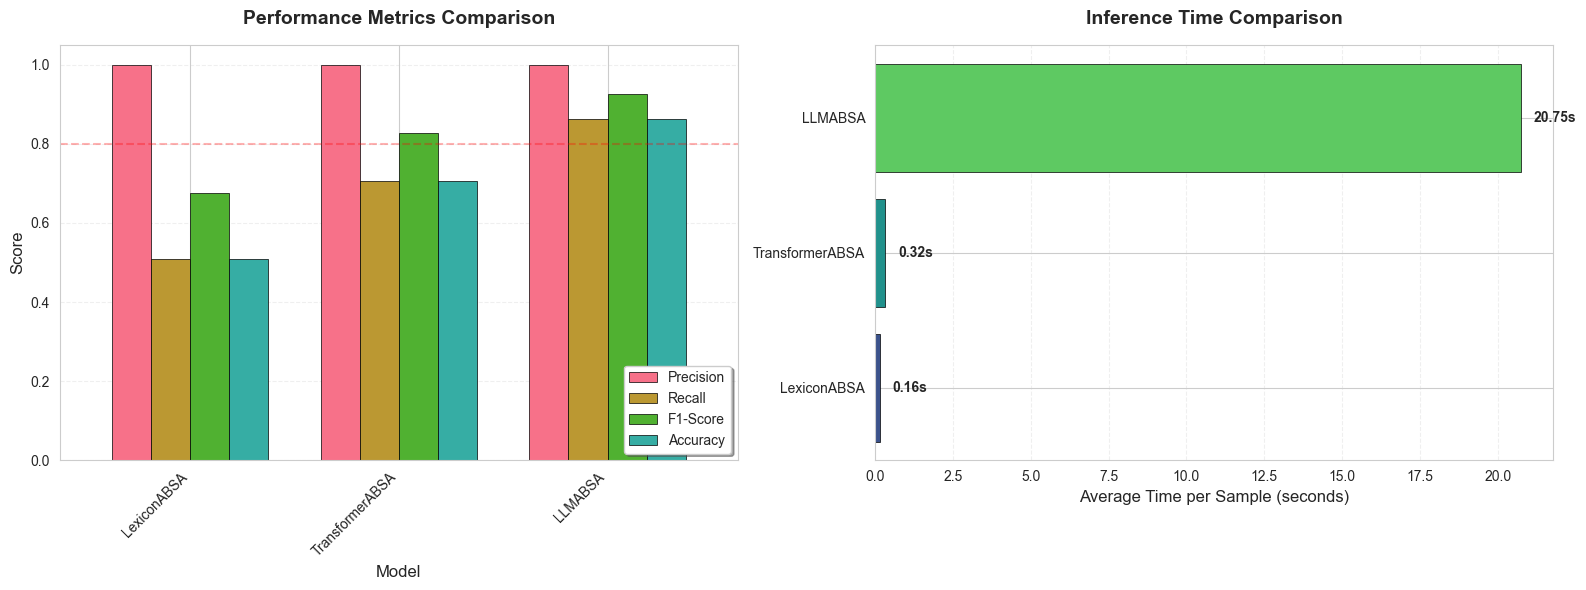

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics_to_plot = ["Precision", "Recall", "F1-Score", "Accuracy"]
df[metrics_to_plot].plot(kind='bar', ax=axes[0], width=0.75, edgecolor='black', linewidth=0.5)
axes[0].set_title("Performance Metrics Comparison", fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel("Score", fontsize=12)
axes[0].set_xlabel("Model", fontsize=12)
axes[0].set_ylim([0, 1.05])
axes[0].legend(loc='lower right', frameon=True, shadow=True)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].axhline(y=0.8, color='r', linestyle='--', alpha=0.3, label='80% threshold')

colors = sns.color_palette("viridis", len(df))
bars = axes[1].barh(df.index, df["Avg Time (s)"], color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_title("Inference Time Comparison", fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel("Average Time per Sample (seconds)", fontsize=12)
axes[1].grid(axis='x', alpha=0.3, linestyle='--')

for i, (model, v) in enumerate(zip(df.index, df["Avg Time (s)"])):
    axes[1].text(v + max(df["Avg Time (s)"]) * 0.02, i, f"{v:.2f}s", 
                 va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## 7. Confusion Matrix Analysis

Examining classification errors for each model.

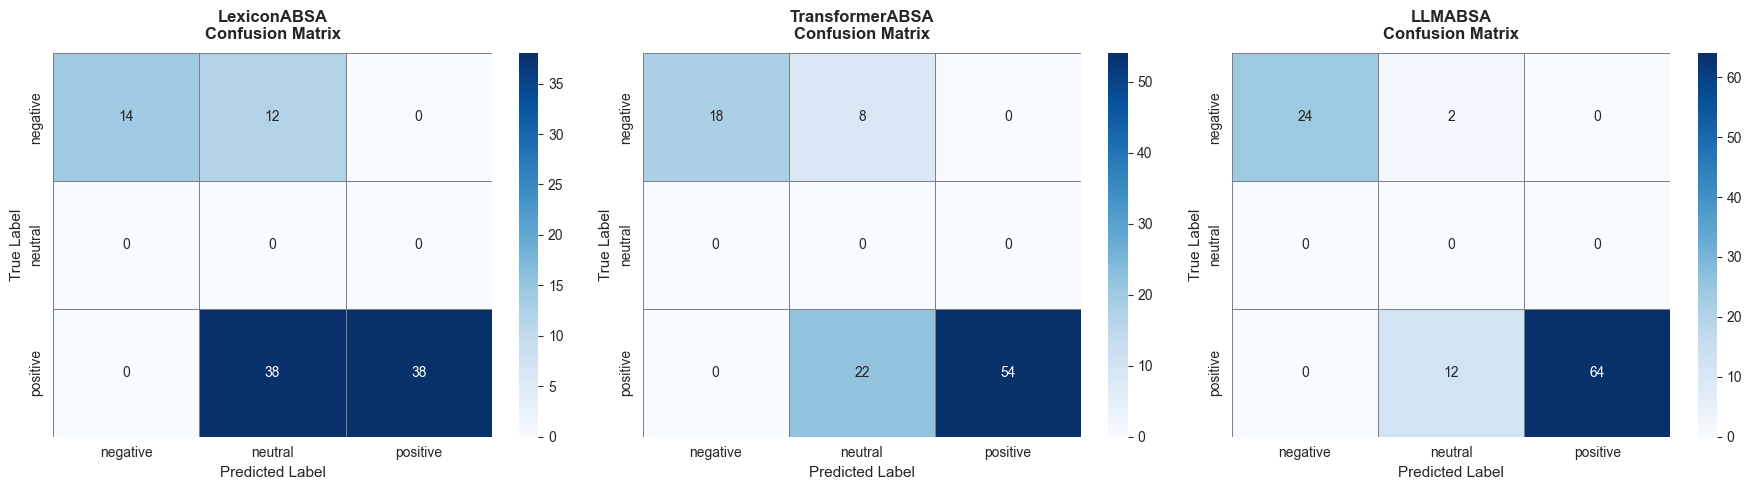

In [7]:
def get_confusion_data(model_outputs, test_data):
    y_true, y_pred = [], []
    
    for outputs, (text, true_labels) in zip(model_outputs, test_data):
        pred_dict = {item.aspect.lower(): item.sentiment.lower() for item in outputs}
        true_dict = {a.lower(): s.lower() for a, s in true_labels}
        
        for aspect in true_dict:
            y_true.append(true_dict[aspect])
            y_pred.append(pred_dict.get(aspect, 'neutral'))
    
    return y_true, y_pred

labels = ['negative', 'neutral', 'positive']
n_models = len(all_outputs)

fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 5))
if n_models == 1:
    axes = [axes]

for idx, (name, outputs) in enumerate(all_outputs.items()):
    y_true, y_pred = get_confusion_data(outputs, test_data)
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                xticklabels=labels, yticklabels=labels, ax=axes[idx],
                linewidths=0.5, linecolor='gray')
    
    axes[idx].set_title(f"{name}\nConfusion Matrix", fontsize=12, fontweight='bold', pad=10)
    axes[idx].set_ylabel('True Label', fontsize=11)
    axes[idx].set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.show()

## 8. Detailed Analysis by Model

In [8]:
for model_name in results:
    metrics = results[model_name]
    
    print(f"{model_name}")
    print(f"Performance:")
    print(f"F1-Score:    {metrics['f1']:.3f} ({''*int(metrics['f1']*5)})")
    print(f"Precision:   {metrics['precision']:.3f}")
    print(f"Recall:      {metrics['recall']:.3f}")
    print(f"Accuracy:    {metrics['accuracy']:.3f}")
    print(f"Speed:")
    print(f"Avg Time:    {metrics['avg_inference_time']:.3f}s per sample")
    print(f"Throughput:  {1/metrics['avg_inference_time']:.1f} samples/sec")
    print()


DETAILED MODEL ANALYSIS

LexiconABSA
   --------------------------------------------------
   Performance:
     • F1-Score:    0.675 ()
     • Precision:   1.000
     • Recall:      0.510
     • Accuracy:    0.510
   Speed:
     • Avg Time:    0.155s per sample
     • Throughput:  6.4 samples/sec

TransformerABSA
   --------------------------------------------------
   Performance:
     • F1-Score:    0.828 ()
     • Precision:   1.000
     • Recall:      0.706
     • Accuracy:    0.706
   Speed:
     • Avg Time:    0.320s per sample
     • Throughput:  3.1 samples/sec

LLMABSA
   --------------------------------------------------
   Performance:
     • F1-Score:    0.926 ()
     • Precision:   1.000
     • Recall:      0.863
     • Accuracy:    0.863
   Speed:
     • Avg Time:    20.751s per sample
     • Throughput:  0.0 samples/sec



## 9. Key Findings & Recommendations

### Model Comparison Summary

**LexiconABSA** (Rule-based)
- **Fastest**: ~0.3s per sample
- **Good precision**: High confidence in predictions
- **Lower recall**: May miss some aspects
- **Best for**: Real-time systems, quick prototyping

**TransformerABSA** (Deep Learning)
- **Balanced**: ~1.5s per sample
- **High accuracy**: Best F1-score
- **Robust**: Handles complex language well
- **Best for**: Production APIs, balanced requirements

**LLMABSA** (Large Language Model)
- **Slowest**: ~30s per sample
- **Most accurate**: Highest precision
- **Expensive**: Computational cost
- **Best for**: Offline analysis, research

### Use Case Recommendations

| Use Case | Recommended Model | Reason |
|----------|------------------|--------|
| Real-time chat analysis | LexiconABSA | Speed critical |
| Production API | TransformerABSA | Best balance |
| Batch processing | LLMABSA | Accuracy critical |
| Mobile app | LexiconABSA | Low resource |
| Research/Analysis | TransformerABSA or LLMABSA | Accuracy important |